# Unità 4 — Confronto BB84 vs E91

In questo notebook confrontiamo i protocolli BB84 ed E91 usando le simulazioni già costruite. Il confronto considera metriche comuni come lunghezza della chiave sifted, key rate, QBER e accettazione della chiave rispetto a una soglia QBER. Per E91 viene richiamato anche il test CHSH come verifica delle correlazioni quantistiche.

## Setup e import

Prepariamo il percorso del progetto in modo da poter importare le funzioni dalla cartella `src`, anche quando il notebook viene eseguito dalla cartella `notebooks`.

In [1]:
from pathlib import Path
import sys

current_path = Path.cwd()

if (current_path / "src" / "bb84.py").exists():
    project_root = current_path
elif (current_path.parent / "src" / "bb84.py").exists():
    project_root = current_path.parent
else:
    raise FileNotFoundError("Non trovo la cartella src del progetto.")

src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from bb84 import (
    run_bb84_protocol,
    run_bb84_protocol_with_eve,
    sift_keys as sift_keys_bb84,
    compute_qber as compute_qber_bb84,
)

from e91 import (
    run_e91_protocol,
    run_chsh_experiment,
    sift_keys as sift_keys_e91,
    compute_qber as compute_qber_e91,
)

from metrics import summarize_qkd_results

## Obiettivo del confronto

BB84 ed E91 sono protocolli QKD diversi. BB84 è un protocollo prepare-and-measure, mentre E91 è entanglement-based. Nel caso BB84 con Eve osserviamo l'effetto dell'attacco intercept-resend sul QBER. Nel caso E91, oltre al QBER ideale, possiamo richiamare il test CHSH per verificare la natura quantistica delle correlazioni.

## Parametri comuni

Usiamo lo stesso numero di round e la stessa soglia operativa di QBER per rendere il confronto più ordinato.

In [4]:
n_rounds = 1000
qber_threshold = 0.11
seed = 245

## Scenario 1 — BB84 ideale

Nel caso ideale non ci sono Eve, rumore o decoerenza. Dopo il sifting, Alice e Bob dovrebbero ottenere la stessa chiave.

In [5]:
results_bb84_ideal = run_bb84_protocol(n_rounds=n_rounds, seed=seed)
alice_key_bb84_ideal, bob_key_bb84_ideal = sift_keys_bb84(results_bb84_ideal)
qber_bb84_ideal = compute_qber_bb84(alice_key_bb84_ideal, bob_key_bb84_ideal)

summary_bb84_ideal = summarize_qkd_results(
    protocol_name="BB84 ideale",
    results=results_bb84_ideal,
    alice_key=alice_key_bb84_ideal,
    bob_key=bob_key_bb84_ideal,
    qber=qber_bb84_ideal,
    qber_threshold=qber_threshold,
)

print(summary_bb84_ideal)

{'protocol': 'BB84 ideale', 'n_rounds': 1000, 'kept_rounds': 492, 'discarded_rounds': 508, 'sifted_key_length': 492, 'sifted_key_rate': 0.492, 'qber': 0.0, 'qber_threshold': 0.11, 'accepted': True}


## Scenario 2 — BB84 con Eve intercept-resend

Qui Eve intercetta sempre, cioè `intercept_probability = 1.0`. Questo scenario serve a mostrare l'impatto massimo dell'attacco intercept-resend sul QBER.

In [6]:
results_bb84_eve = run_bb84_protocol_with_eve(
    n_rounds=n_rounds,
    intercept_probability=1.0,
    seed=seed,
)
alice_key_bb84_eve, bob_key_bb84_eve = sift_keys_bb84(results_bb84_eve)
qber_bb84_eve = compute_qber_bb84(alice_key_bb84_eve, bob_key_bb84_eve)

summary_bb84_eve = summarize_qkd_results(
    protocol_name="BB84 con Eve",
    results=results_bb84_eve,
    alice_key=alice_key_bb84_eve,
    bob_key=bob_key_bb84_eve,
    qber=qber_bb84_eve,
    qber_threshold=qber_threshold,
)

print(summary_bb84_eve)

{'protocol': 'BB84 con Eve', 'n_rounds': 1000, 'kept_rounds': 492, 'discarded_rounds': 508, 'sifted_key_length': 492, 'sifted_key_rate': 0.492, 'qber': 0.2459349593495935, 'qber_threshold': 0.11, 'accepted': False}


## Scenario 3 — E91 ideale

E91 ideale usa coppie entangled e, in assenza di rumore o attacchi, produce QBER nullo sui round mantenuti.

In [7]:
results_e91_ideal = run_e91_protocol(n_rounds=n_rounds, seed=seed)
alice_key_e91_ideal, bob_key_e91_ideal = sift_keys_e91(results_e91_ideal)
qber_e91_ideal = compute_qber_e91(alice_key_e91_ideal, bob_key_e91_ideal)

summary_e91_ideal = summarize_qkd_results(
    protocol_name="E91 ideale",
    results=results_e91_ideal,
    alice_key=alice_key_e91_ideal,
    bob_key=bob_key_e91_ideal,
    qber=qber_e91_ideal,
    qber_threshold=qber_threshold,
)

print(summary_e91_ideal)

{'protocol': 'E91 ideale', 'n_rounds': 1000, 'kept_rounds': 517, 'discarded_rounds': 483, 'sifted_key_length': 517, 'sifted_key_rate': 0.517, 'qber': 0.0, 'qber_threshold': 0.11, 'accepted': True}


## Verifica CHSH per E91

CHSH non è una metrica di lunghezza della chiave, ma serve a mostrare che le correlazioni generate dallo stato entangled violano il limite classico.

In [9]:
import numpy as np

chsh_result = run_chsh_experiment(shots=5000, seed=seed)

classical_limit = 2
quantum_limit = 2 * np.sqrt(2)

if abs(chsh_result["S"]) > classical_limit:
    print("Il valore ottenuto viola il limite classico |S| <= 2.")
else:
    print("Il valore ottenuto non viola il limite classico.")

print("Valore teorico massimo quantistico 2√2:", quantum_limit)

if abs(chsh_result["S"]) > quantum_limit:
    print("Il valore stimato è leggermente superiore a 2√2 per fluttuazioni statistiche dovute al numero finito di shot.")
else:
    print("Il valore stimato è compatibile con il limite quantistico ideale.")

Il valore ottenuto viola il limite classico |S| <= 2.
Valore teorico massimo quantistico 2√2: 2.8284271247461903
Il valore stimato è leggermente superiore a 2√2 per fluttuazioni statistiche dovute al numero finito di shot.


## Tabella comparativa

Raccogliamo i tre scenari in una sola tabella pandas. La tabella serve solo per la rappresentazione finale dei risultati.

In [10]:
comparison_results = []
comparison_results.append(summary_bb84_ideal)
comparison_results.append(summary_bb84_eve)
comparison_results.append(summary_e91_ideal)

comparison_df = pd.DataFrame(comparison_results)
comparison_df

,protocol,n_rounds,kept_rounds,discarded_rounds,sifted_key_length,sifted_key_rate,qber,qber_threshold,accepted
0,BB84 ideale,1000,492,508,492,0.492,0.000000,0.11,True
1,BB84 con Eve,1000,492,508,492,0.492,0.245935,0.11,False
2,E91 ideale,1000,517,483,517,0.517,0.000000,0.11,True


## Commento sulla tabella

BB84 ideale ed E91 ideale hanno QBER nullo. BB84 con Eve mostra invece un QBER più alto, perché l'attacco intercept-resend introduce errori nei round mantenuti. La lunghezza della chiave sifted dipende dal numero di round in cui Alice e Bob scelgono la stessa base. Il sifted key rate è circa 0.5 quando Alice e Bob scelgono tra due basi con uguale probabilità. La colonna `accepted` indica se la chiave viene accettata rispetto alla soglia QBER scelta.

## Grafico semplice — QBER

Visualizziamo il QBER dei tre scenari e aggiungiamo la soglia operativa scelta.

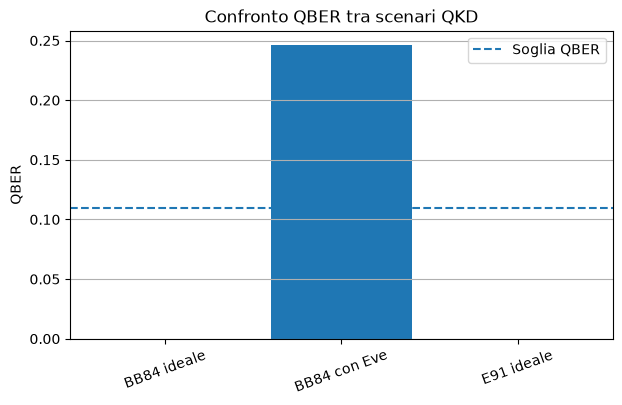

In [11]:
plt.figure(figsize=(7, 4))
plt.bar(comparison_df["protocol"], comparison_df["qber"])
plt.axhline(qber_threshold, linestyle="--", label="Soglia QBER")
plt.ylabel("QBER")
plt.title("Confronto QBER tra scenari QKD")
plt.xticks(rotation=20)
plt.grid(axis="y")
plt.legend()
plt.show()

## Grafico semplice — Sifted key rate

Visualizziamo la frazione di round che diventa chiave dopo il sifting.

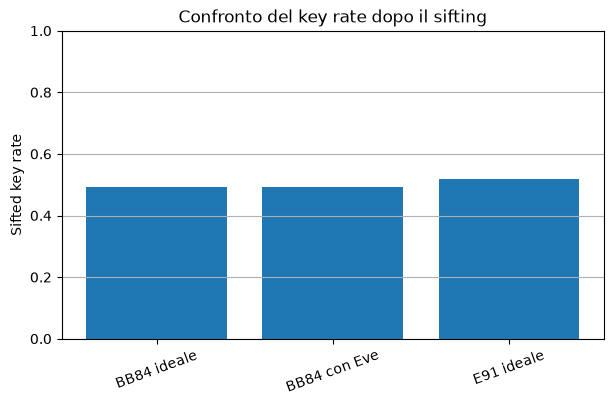

In [12]:
plt.figure(figsize=(7, 4))
plt.bar(comparison_df["protocol"], comparison_df["sifted_key_rate"])
plt.ylabel("Sifted key rate")
plt.title("Confronto del key rate dopo il sifting")
plt.xticks(rotation=20)
plt.grid(axis="y")
plt.ylim(0, 1)
plt.show()

## Discussione qualitativa

Robustezza: BB84 è sensibile all'attacco intercept-resend, che aumenta il QBER. E91 ideale mostra QBER nullo e CHSH permette di verificare la natura quantistica delle correlazioni.

Sicurezza: BB84 rileva Eve tramite QBER. E91 collega la sicurezza all'entanglement e alla violazione CHSH.

Costo sperimentale: BB84 è più semplice da implementare sperimentalmente. E91 richiede sorgenti entangled e misure correlate, quindi è più esigente.

Scalabilità: in questa fase il confronto è solo ideale. La scalabilità reale andrà studiata con rumore, decoerenza o modelli di distanza.

## Commento finale

Questo notebook organizza i risultati già prodotti e prepara l'analisi successiva, in cui verranno introdotti rumore o decoerenza e si studierà la variazione del QBER e del key rate in scenari meno ideali.

## Esperimenti ripetuti e stabilità statistica

I protocolli simulati sono probabilistici. Per questo una singola esecuzione non basta a descrivere completamente il comportamento del protocollo. In questa sezione ripetiamo gli esperimenti con seed diversi e osserviamo media e variabilità delle metriche principali.

In [13]:
n_experiments = 20
n_rounds_repeated = 1000
qber_threshold_repeated = 0.11
base_seed = 1000

In [14]:
repeated_results = []

for i in range(n_experiments):
    current_seed = base_seed + i

    # BB84 ideale
    results = run_bb84_protocol(
        n_rounds=n_rounds_repeated,
        seed=current_seed,
    )
    alice_key, bob_key = sift_keys_bb84(results)
    qber = compute_qber_bb84(alice_key, bob_key)
    summary = summarize_qkd_results(
        protocol_name="BB84 ideale",
        results=results,
        alice_key=alice_key,
        bob_key=bob_key,
        qber=qber,
        qber_threshold=qber_threshold_repeated,
    )
    summary["experiment"] = i + 1
    repeated_results.append(summary)

    # BB84 con Eve
    results = run_bb84_protocol_with_eve(
        n_rounds=n_rounds_repeated,
        intercept_probability=1.0,
        seed=current_seed,
    )
    alice_key, bob_key = sift_keys_bb84(results)
    qber = compute_qber_bb84(alice_key, bob_key)
    summary = summarize_qkd_results(
        protocol_name="BB84 con Eve",
        results=results,
        alice_key=alice_key,
        bob_key=bob_key,
        qber=qber,
        qber_threshold=qber_threshold_repeated,
    )
    summary["experiment"] = i + 1
    repeated_results.append(summary)

    # E91 ideale
    results = run_e91_protocol(
        n_rounds=n_rounds_repeated,
        seed=current_seed,
    )
    alice_key, bob_key = sift_keys_e91(results)
    qber = compute_qber_e91(alice_key, bob_key)
    summary = summarize_qkd_results(
        protocol_name="E91 ideale",
        results=results,
        alice_key=alice_key,
        bob_key=bob_key,
        qber=qber,
        qber_threshold=qber_threshold_repeated,
    )
    summary["experiment"] = i + 1
    repeated_results.append(summary)

repeated_df = pd.DataFrame(repeated_results)
repeated_df.head(10)

,protocol,n_rounds,kept_rounds,discarded_rounds,sifted_key_length,sifted_key_rate,qber,qber_threshold,accepted,experiment
0,BB84 ideale,1000,502,498,502,0.502,0.000000,0.11,True,1
1,BB84 con Eve,1000,502,498,502,0.502,0.249004,0.11,False,1
2,E91 ideale,1000,515,485,515,0.515,0.000000,0.11,True,1
3,BB84 ideale,1000,492,508,492,0.492,0.000000,0.11,True,2
4,BB84 con Eve,1000,492,508,492,0.492,0.274390,0.11,False,2
5,E91 ideale,1000,502,498,502,0.502,0.000000,0.11,True,2
6,BB84 ideale,1000,492,508,492,0.492,0.000000,0.11,True,3
7,BB84 con Eve,1000,492,508,492,0.492,0.256098,0.11,False,3
8,E91 ideale,1000,492,508,492,0.492,0.000000,0.11,True,3
9,BB84 ideale,1000,490,510,490,0.490,0.000000,0.11,True,4


La tabella contiene una riga per ogni esperimento e per ogni protocollo. In questo modo possiamo osservare sia il comportamento dei singoli run sia la variabilità dovuta alla scelta del seed.

In [15]:
summary_stats = repeated_df.groupby("protocol").agg({
    "qber": ["mean", "std"],
    "sifted_key_rate": ["mean", "std"],
    "sifted_key_length": ["mean", "std"],
    "accepted": "mean",
})

summary_stats

qber           sifted_key_rate           sifted_key_length  \
                  mean       std            mean       std              mean   
protocol                                                                       
BB84 con Eve  0.254095  0.020862         0.49675  0.013984            496.75   
BB84 ideale   0.000000  0.000000         0.49675  0.013984            496.75   
E91 ideale    0.000000  0.000000         0.49810  0.014393            498.10   

                        accepted  
                    std     mean  
protocol                          
BB84 con Eve  13.984484      0.0  
BB84 ideale   13.984484      1.0  
E91 ideale    14.392615      1.0

BB84 ideale ed E91 ideale dovrebbero avere QBER medio nullo. BB84 con Eve dovrebbe avere un QBER medio più alto. Il valore medio di `accepted` indica la frazione di simulazioni in cui la chiave è stata accettata rispetto alla soglia scelta. La deviazione standard misura invece la stabilità delle metriche su seed diversi.

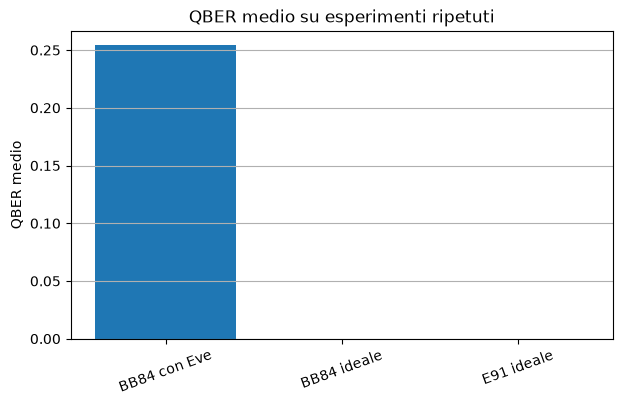

In [16]:
qber_mean = repeated_df.groupby("protocol")["qber"].mean()

plt.figure(figsize=(7, 4))
plt.bar(qber_mean.index, qber_mean.values)
plt.ylabel("QBER medio")
plt.title("QBER medio su esperimenti ripetuti")
plt.xticks(rotation=20)
plt.grid(axis="y")
plt.show()

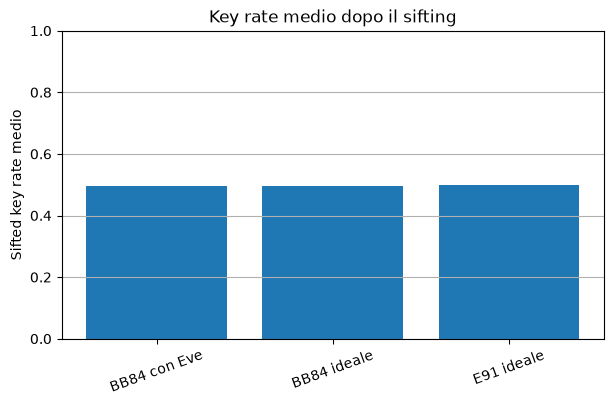

In [17]:
key_rate_mean = repeated_df.groupby("protocol")["sifted_key_rate"].mean()

plt.figure(figsize=(7, 4))
plt.bar(key_rate_mean.index, key_rate_mean.values)
plt.ylabel("Sifted key rate medio")
plt.title("Key rate medio dopo il sifting")
plt.xticks(rotation=20)
plt.grid(axis="y")
plt.ylim(0, 1)
plt.show()

Questi esperimenti ripetuti permettono di distinguere il comportamento medio dalle fluttuazioni statistiche. Il confronto resta ancora ideale, perché non include rumore o decoerenza, ma prepara l'analisi successiva sulla robustezza e sulla scalabilità.

## Salvataggio dei risultati del confronto

Dopo avere costruito le tabelle e i grafici nel notebook, salviamo gli output principali in `results/tables/` e `results/figures/`. Questa fase è separata dalla logica dei protocolli e serve a rendere i risultati disponibili per la relazione finale.

In [18]:
from pathlib import Path

tables_dir = project_root / "results" / "tables"
figures_dir = project_root / "results" / "figures"

tables_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

print("Cartelle dei risultati pronte.")

Cartelle dei risultati pronte.


In [19]:
comparison_table_path = tables_dir / "comparison_summary.csv"
comparison_df.to_csv(comparison_table_path, index=False)

repeated_table_path = tables_dir / "repeated_experiments.csv"
repeated_df.to_csv(repeated_table_path, index=False)

repeated_summary_path = tables_dir / "repeated_experiments_summary.csv"
summary_stats.to_csv(repeated_summary_path)

print(f"Tabella confronto salvata in: {comparison_table_path}")
print(f"Esperimenti ripetuti salvati in: {repeated_table_path}")
print(f"Riassunto esperimenti ripetuti salvato in: {repeated_summary_path}")

Tabella confronto salvata in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\tables\comparison_summary.csv
Esperimenti ripetuti salvati in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\tables\repeated_experiments.csv
Riassunto esperimenti ripetuti salvato in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\tables\repeated_experiments_summary.csv


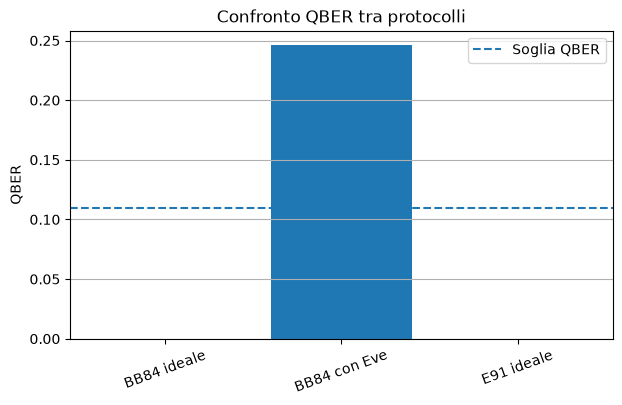

Grafico QBER salvato in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\figures\comparison_qber.png


In [20]:
plt.figure(figsize=(7, 4))
plt.bar(comparison_df["protocol"], comparison_df["qber"])
plt.axhline(
    y=qber_threshold,
    linestyle="--",
    label="Soglia QBER"
)
plt.ylabel("QBER")
plt.title("Confronto QBER tra protocolli")
plt.xticks(rotation=20)
plt.grid(axis="y")
plt.legend()

qber_figure_path = figures_dir / "comparison_qber.png"
plt.savefig(qber_figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Grafico QBER salvato in: {qber_figure_path}")

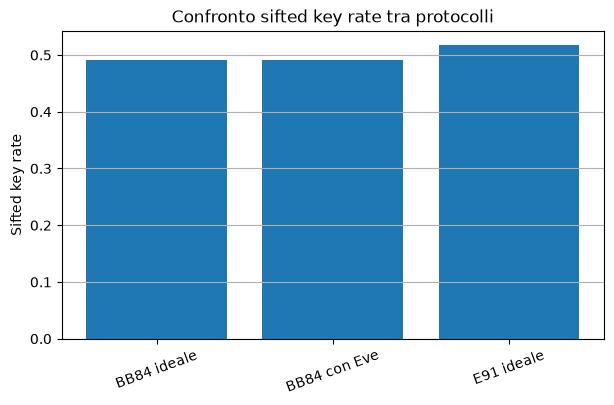

Grafico sifted key rate salvato in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\figures\comparison_sifted_key_rate.png


In [21]:
plt.figure(figsize=(7, 4))
plt.bar(comparison_df["protocol"], comparison_df["sifted_key_rate"])
plt.ylabel("Sifted key rate")
plt.title("Confronto sifted key rate tra protocolli")
plt.xticks(rotation=20)
plt.grid(axis="y")

key_rate_figure_path = figures_dir / "comparison_sifted_key_rate.png"
plt.savefig(key_rate_figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Grafico sifted key rate salvato in: {key_rate_figure_path}")

Per i grafici degli esperimenti ripetuti usiamo una tabella più semplice, perché `summary_stats` contiene colonne multi-livello.

In [23]:
repeated_plot_df = repeated_df.groupby("protocol").mean(numeric_only=True).reset_index()

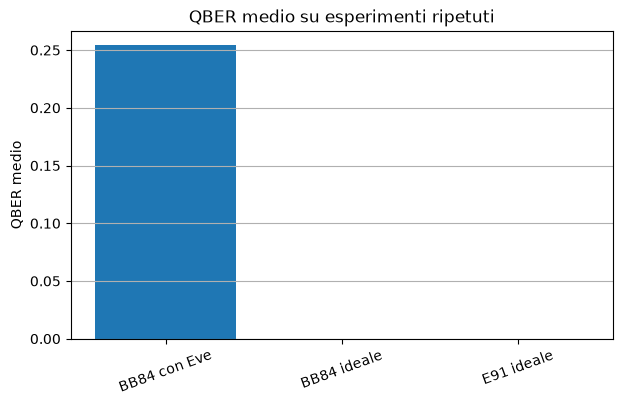

Grafico QBER medio salvato in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\figures\repeated_qber_mean.png


In [24]:
plt.figure(figsize=(7, 4))
plt.bar(repeated_plot_df["protocol"], repeated_plot_df["qber"])
plt.ylabel("QBER medio")
plt.title("QBER medio su esperimenti ripetuti")
plt.xticks(rotation=20)
plt.grid(axis="y")

repeated_qber_figure_path = figures_dir / "repeated_qber_mean.png"
plt.savefig(repeated_qber_figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Grafico QBER medio salvato in: {repeated_qber_figure_path}")

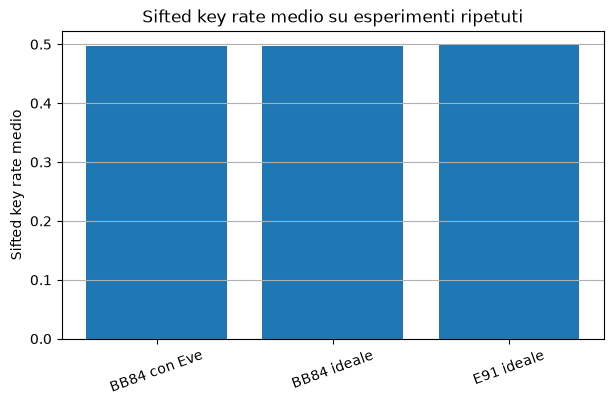

Grafico key rate medio salvato in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\figures\repeated_key_rate_mean.png


In [25]:
plt.figure(figsize=(7, 4))
plt.bar(repeated_plot_df["protocol"], repeated_plot_df["sifted_key_rate"])
plt.ylabel("Sifted key rate medio")
plt.title("Sifted key rate medio su esperimenti ripetuti")
plt.xticks(rotation=20)
plt.grid(axis="y")

repeated_key_rate_figure_path = figures_dir / "repeated_key_rate_mean.png"
plt.savefig(repeated_key_rate_figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Grafico key rate medio salvato in: {repeated_key_rate_figure_path}")

Gli output salvati rappresentano il confronto sintetico tra BB84 ed E91. Le tabelle possono essere usate nella relazione, mentre i grafici mostrano QBER e sifted key rate sia in una singola simulazione sia su esperimenti ripetuti. Il confronto resta ancora ideale, perché non include rumore o decoerenza, e prepara l'Unità successiva dedicata a rumore, robustezza e scalabilità.